<a href="https://colab.research.google.com/github/aldo02032004/naufaldo.github.io/blob/main/Visual_Report_LH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CELL 1 - INSTALL & IMPORT

In [105]:
!pip install -q pandas transformers torch openpyxl requests geopandas flashtext matplotlib

import pandas as pd
import numpy as np
import re
import html
import os
import requests
import time
from collections import Counter
import torch
from transformers import pipeline
from IPython.display import display # Ditambahkan agar display() tidak ditandai undefined
from tqdm.auto import tqdm
from flashtext import KeywordProcessor
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, MultiPolygon

pd.set_option("display.max_colwidth", 150)

# CELL 2 - INGESTI DATA DARI GOOGLE SHEETS


In [106]:
# SHEET_ID = "1WOtqrI1GIZfz4eFAVHfLONi3eMxntBobhd24iGGNC6g"
# GID = "1525349719"

# export_url = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}"

# def load_raw_data(url: str) -> pd.DataFrame:
#     df = pd.read_csv(url, skiprows=1)
#     df.columns = [c.strip() for c in df.columns]

#     expected_cols = ["No", "Headline", "Mentions", "Date", "Sentiment", "Author"]
#     missing = [c for c in expected_cols if c not in df.columns]
#     if missing:
#         print(f"[WARNING] Kolom hilang: {missing}")

#     df = df.dropna(subset=["Mentions"]).reset_index(drop=True)

#     # Supaya tidak error saat list 'expected_cols' mengandung kolom yang tidak ada,
#     # kita hanya filter kolom yang benar-benar exist di dataframe
#     available_cols = [c for c in expected_cols if c in df.columns]
#     df = df[available_cols]

#     return df

# df_raw = load_raw_data(export_url)
# print(f"Data berhasil dimuat: {df_raw.shape}")
# display(df_raw.head())

# CELL 2 - INGESTI DATA DARI EXCELL


In [107]:
import re
import requests
import pandas as pd
from io import BytesIO

def resolve_xlsx_url(source: str) -> str:
    """Ubah link Google Sheets/Drive jadi url download .xlsx."""
    sheet_match = re.search(r"docs\.google\.com/spreadsheets/d/([a-zA-Z0-9-_]+)", source)
    drive_match = re.search(r"drive\.google\.com/file/d/([a-zA-Z0-9-_]+)", source)

    if sheet_match:
        return f"https://docs.google.com/spreadsheets/d/{sheet_match.group(1)}/export?format=xlsx"
    if drive_match:
        return f"https://drive.google.com/uc?export=download&id={drive_match.group(1)}"
    return source  # sudah berupa path/url .xlsx


def load_raw_data(source: str, sheet_name=0, skiprows: int = 1) -> pd.DataFrame:
    url = resolve_xlsx_url(source)

    if url.startswith("http"):
        resp = requests.get(url)
        resp.raise_for_status()
        df = pd.read_excel(BytesIO(resp.content), sheet_name=sheet_name, skiprows=skiprows)
    else:
        df = pd.read_excel(url, sheet_name=sheet_name, skiprows=skiprows)

    df.columns = [c.strip() for c in df.columns]

    expected_cols = ["No", "Headline", "Mentions", "Date", "Sentiment", "Author"]
    missing = [c for c in expected_cols if c not in df.columns]
    if missing:
        print(f"[WARNING] Kolom hilang: {missing}")

    df = df.dropna(subset=["Mentions"]).reset_index(drop=True)
    available_cols = [c for c in expected_cols if c in df.columns]
    return df[available_cols]


SOURCE = "https://docs.google.com/spreadsheets/d/1tC_fETuN2u8L86_2uhRYAW_NX0iiWwJC/edit?usp=sharing&ouid=116825097454650626545&rtpof=true&sd=true"

df_raw = load_raw_data(SOURCE)
print(f"Data berhasil dimuat: {df_raw.shape}")
display(df_raw.head())

Data berhasil dimuat: (25379, 6)


,No,Headline,Mentions,Date,Sentiment,Author
0,1,"Cegah Dampak Karhutla, Pemkot Pekanbaru Terapkan 2 Hari PJJ untuk TK-SMP",Pemkot Pekanbaru terapkan Pembelajaran Jarak Jauh untuk PAUD hingga SMP. (dok.istimewa) Foto: Pemkot Pekanbaru terapkan Pembelajaran Jarak Jauh un...,2026-09-06 23:59:33,Negative,news.detik.com
1,2,"Abu Vulkanik Anak Krakatau, Sekolah di Tangsel Terapkan PJJ 1 Hari",Dinas Pendidikan dan Kebudayaan (Dikbud) Kota Tangerang Selatan mengalihkan sementara kegiatan belajar mengajar menjadi Pembelajaran Jarak Jauh (P...,2026-09-06 23:56:06,Positive,tangerangonline.id
2,3,"Kebakaran Kebun Raya Sriwijaya, pemadaman diperkuat dari udara","ANTARA - Kebakaran hutan dan lahan di kawasan Kebun Raya Sriwijaya, Kabupaten Ogan Ilir, Sumatera Selatan, memasuki hari kelima. Pemadaman diperku...",2026-09-06 23:55:59,Neutral,www.antaranews.com
3,4,Keren! Penyanyi Sherina Padamkan Api Karhutla,Keren! Penyanyi Sherina Padamkan Api Karhutla. Kebakaran hutan dan lahan (Karhutla) di Kalimantan Tengah memanggil kepedulian penyanyi Sherina Mu...,2026-09-06 23:54:51,Positive,Mata Warga
4,5,"Kebakaran Ijen meluas, pemadaman diperkuat dengan water bombing","ANTARA - Upaya pemadaman kebakaran hutan di kawasan Pegunungan Ijen, Jawa Timur, diperkuat dengan operasi udara menggunakan helikopter water bombi...",2026-09-06 23:54:08,Neutral,www.antaranews.com


# CELL 3 - DATA CLEANING

In [114]:
from tqdm.auto import tqdm
tqdm.pandas()

URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
HASHTAG_PATTERN = re.compile(r'#\S+')
MENTION_PATTERN = re.compile(r'@\S+')

BOILERPLATE_PATTERNS = [
    r"Dilarang keras mengambil konten.*?ANTARA\.",
    r"Kirim\s*Komentar menjadi tanggung-?jawab Anda sesuai UU ITE\.",
    r"Yuk Subscribe.*?(?=\n\n|\Z)",
    r"Follow (WA Channel|our Official).*?(?=\n\n|\Z)",
    r"Like our Official Facebook.*?(?=\n\n|\Z)",
    r"Uploader\s*:\s*\S+",
    r"Tanggal Tayang\s*:.*",
    r"Selengkapnya baca di\s*:\s*\S+",
]
BOILERPLATE_RE = re.compile("|".join(BOILERPLATE_PATTERNS), flags=re.IGNORECASE | re.DOTALL)

def clean_text(raw_text: str) -> str:
    if not isinstance(raw_text, str):
        return ""
    text = html.unescape(raw_text)
    text = BOILERPLATE_RE.sub(" ", text)
    text = URL_PATTERN.sub(" ", text)
    text = HASHTAG_PATTERN.sub(" ", text)
    text = MENTION_PATTERN.sub(" ", text)
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{2,}', '\n', text)
    return text.strip()

df_clean = df_raw.copy()

print("[INFO] Membersihkan teks...")
df_clean["clean_text"] = df_clean["Mentions"].progress_apply(clean_text)
df_clean = df_clean[df_clean["clean_text"].str.len() > 20].reset_index(drop=True)

df_clean["doc_id"] = [f"DOC-{i:05d}" for i in range(len(df_clean))]

df_clean["dedupe_key"] = (
    df_clean["Headline"].astype(str).str.strip().str.lower() + "||" +
    df_clean["clean_text"].astype(str).str[:200].str.strip().str.lower()
)
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset="dedupe_key", keep="first").reset_index(drop=True)
print(f"[INFO] Dedup: {before} -> {len(df_clean)} baris")
df_clean = df_clean.drop(columns="dedupe_key")

df_clean["search_text"] = df_clean["Headline"].str.lower().fillna("") + " " + df_clean["clean_text"].fillna("")

df_clean["clean_text"]  = df_clean["clean_text"].str.lower()
df_clean["search_text"] = df_clean["search_text"].str.lower()

slang_dict = {
    "gak": "tidak", "ga": "tidak", "nggak": "tidak", "tdk": "tidak",
    "bgt": "banget", "yg": "yang", "krn": "karena", "krna": "karena", "karna": "karena",
    "sm": "sama", "utk": "untuk", "dr": "dari", "skrg": "sekarang",
    "dgn": "dengan", "dg": "dengan", "org": "orang",
    "tp": "tapi", "spt": "seperti", "kayak": "seperti", "kaya": "seperti", "kyk": "seperti",
    "blm": "belum", "jgn": "jangan", "emg": "memang", "emang": "memang",
    "jd": "jadi", "jg": "juga", "aja": "saja", "aj": "saja",
    "udah": "sudah", "udh": "sudah", "dah": "sudah",
    "gmn": "bagaimana", "knp": "kenapa", "kalo": "kalau", "klo": "kalau",
    "trs": "terus", "trus": "terus", "gini": "begini", "gitu": "begitu",
    "sy": "saya", "km": "kamu", "gw": "saya", "gue": "saya", "lo": "kamu", "lu": "kamu",
    "hrs": "harus", "bs": "bisa", "msh": "masih", "dlm": "dalam",
    "sblm": "sebelum", "stlh": "setelah", "pd": "pada", "pgn": "ingin", "pengen": "ingin",
    "liat": "lihat", "abis": "habis",
    "bkn": "bukan", "gpp": "tidak apa-apa", "gapapa": "tidak apa-apa", "gaada": "tidak ada",
    "cmn": "cuma", "cuman": "cuma",
    "mksh": "terima kasih", "makasih": "terima kasih",
    "moga": "semoga", "smoga": "semoga",
    "wkt": "waktu", "cpt": "cepat", "lg": "lagi", "lgi": "lagi",
    "sll": "selalu", "sllu": "selalu", "prnh": "pernah",
    "sndiri": "sendiri", "stiap": "setiap", "byk": "banyak", "dikit": "sedikit",
    "dtg": "datang", "krg": "kurang", "ato": "atau",
    "pke": "pakai", "pake": "pakai", "kudu": "harus", "musti": "harus",
    "denger": "dengar", "kasih": "beri", "bikin": "buat",
    "brp": "berapa", "gmna": "bagaimana", "knpa": "kenapa",
    "walopun": "walaupun",
    "kayanya": "sepertinya", "kykny": "sepertinya", "emgnya": "memangnya",
    "kaga": "tidak", "kagak": "tidak", "ngga": "tidak", "enggak": "tidak", "tak": "tidak",
    "napa": "kenapa", "ngapain": "sedang apa", "ngapa": "kenapa",
    "ente": "kamu", "situ": "kamu", "elu": "kamu", "elo": "kamu",
    "gua": "saya", "gwa": "saya", "ane": "saya", "aq": "saya",
    "dpt": "dapat", "dapet": "dapat",
    "tggl": "tinggal", "tinggl": "tinggal",
    "tmn": "teman", "temen": "teman",
    "sm2": "sama-sama", "sama2": "sama-sama",
    "gmana": "bagaimana", "gimana": "bagaimana",
    "trnyata": "ternyata", "ternyta": "ternyata",
    "jgnkan": "jangankan",
    "sbnrnya": "sebenarnya", "sebenernya": "sebenarnya", "sbnernya": "sebenarnya",
    "sbg": "sebagai", "sbgai": "sebagai",
    "trhdp": "terhadap", "thd": "terhadap", "thdp": "terhadap",
    "diantaranya": "di antaranya", "diantara": "di antara",
    "meski": "meskipun",
    "ngerti": "mengerti", "ngerasa": "merasa", "berasa": "terasa",
    "keliatan": "terlihat", "keliatannya": "terlihatnya",
    "nyari": "mencari", "nyoba": "mencoba", "nunggu": "menunggu",
    "ngasih": "memberi", "ngajak": "mengajak", "ngobrol": "berbicara",
    "nyadar": "sadar",
    "ngerasain": "merasakan", "ngebayangin": "membayangkan",
    "mikir": "berpikir", "mikirin": "memikirkan",
    "ngomongin": "membicarakan",
    "kesel": "kesal", "sebel": "sebal",
    "capek": "lelah", "cape": "lelah",
    "males": "malas", "mager": "malas gerak",
    "seneng": "senang",
    "parah": "sangat", "gila": "sangat", "anjir": "sangat", "anjay": "sangat",
    "mantap": "bagus", "mantul": "bagus", "keren": "bagus",
    "jelek": "buruk", "ancur": "hancur",
    "ngeri": "mengerikan", "serem": "menyeramkan",
    "bego": "bodoh", "goblok": "bodoh", "tolol": "bodoh", "bodo": "bodoh",
    "songong": "sombong", "belagu": "sombong",
    "curhat": "curahan hati",
    "japri": "pesan pribadi", "japrii": "pesan pribadi",
    "bener": "benar", "beneran": "benaran",
    "emank": "memang", "emangnya": "memangnya",
    "makannya": "makanya",
    "makin": "semakin", "kian": "semakin",
    "sangattt": "sangat", "bangettt": "banget", "banget2": "banget",
    "skrng": "sekarang", "skarang": "sekarang",
    "bsk": "besok",
    "kmrn": "kemarin", "kemaren": "kemarin",
    "td": "tadi",
    "entar": "nanti", "ntar": "nanti", "nti": "nanti",
    "detik2": "detik-detik",
    "pemrintah": "pemerintah",
    "korup": "korupsi", "dikorupsi": "korupsi", "ngorupsi": "korupsi",
    "nyolong": "mencuri", "maling": "pencuri",
    "boong": "bohong", "bohong2": "bohong", "hoax": "hoaks", "hoak": "hoaks",
    "settingan": "rekayasa", "settingannya": "rekayasa",
    "php": "janji palsu",
    "ngamuk": "marah", "murka": "marah",
    "unjuk rasa": "demonstrasi",
    "yng": "yang", "dngan": "dengan", "utuk": "untuk",
    "smpai": "sampai", "sampe": "sampai",
    "bwt": "buat", "buatt": "buat",
    "jgnlah": "janganlah",
    "tuhh": "tuh", "sihh": "sih", "dehh": "deh",
}

def normalize_slang(text: str) -> str:
    words = str(text).split()
    return " ".join(slang_dict.get(w, w) for w in words)

print("[INFO] Normalisasi slang...")
df_clean["search_text"] = df_clean["search_text"].progress_apply(normalize_slang)

[INFO] Membersihkan teks...


  0%|          | 0/25379 [00:00<?, ?it/s]

[INFO] Dedup: 25277 -> 12241 baris
[INFO] Normalisasi slang...


  0%|          | 0/12241 [00:00<?, ?it/s]

# CELL 4 - GAZETTEER LOKASI (38 PROVINSI)

In [115]:
LOCATION_TO_PROVINCE = {
    # ---------------- SUMATERA ----------------
    "aceh": "Aceh", "banda aceh": "Aceh", "sabang": "Aceh", "lhokseumawe": "Aceh",
    "langsa": "Aceh", "subulussalam": "Aceh", "pidie": "Aceh", "bireuen": "Aceh",
    "aceh besar": "Aceh", "aceh utara": "Aceh", "aceh timur": "Aceh", "aceh selatan": "Aceh",
    "leuser": "Aceh", "gunung leuser": "Aceh", "taman nasional gunung leuser": "Aceh",

    "sumatera utara": "Sumatera Utara", "sumut": "Sumatera Utara", "medan": "Sumatera Utara",
    "binjai": "Sumatera Utara", "tebing tinggi": "Sumatera Utara", "pematangsiantar": "Sumatera Utara",
    "tanjungbalai": "Sumatera Utara", "sibolga": "Sumatera Utara", "padangsidempuan": "Sumatera Utara",
    "gunungsitoli": "Sumatera Utara", "deli serdang": "Sumatera Utara", "karo": "Sumatera Utara",
    "simalungun": "Sumatera Utara", "tapanuli": "Sumatera Utara", "toba": "Sumatera Utara", "nias": "Sumatera Utara",
    "danau toba": "Sumatera Utara", "sinabung": "Sumatera Utara", "gunung sinabung": "Sumatera Utara",
    "sibayak": "Sumatera Utara", "gunung sibayak": "Sumatera Utara", "nias selatan": "Sumatera Utara",

    "sumatera barat": "Sumatera Barat", "sumbar": "Sumatera Barat", "padang": "Sumatera Barat",
    "bukittinggi": "Sumatera Barat", "pariaman": "Sumatera Barat", "padang panjang": "Sumatera Barat",
    "payakumbuh": "Sumatera Barat", "sawahlunto": "Sumatera Barat", "solok": "Sumatera Barat",
    "agam": "Sumatera Barat", "tanah datar": "Sumatera Barat", "mentawai": "Sumatera Barat", "pesisir selatan": "Sumatera Barat",
    "danau singkarak": "Sumatera Barat", "danau maninjau": "Sumatera Barat", "marapi": "Sumatera Barat", "gunung marapi": "Sumatera Barat",

    "riau": "Riau", "pekanbaru": "Riau", "dumai": "Riau", "bengkalis": "Riau",
    "rokan hilir": "Riau", "rokan hulu": "Riau", "kampar": "Riau", "siak": "Riau",
    "pelalawan": "Riau", "kuantan singingi": "Riau", "indragiri hilir": "Riau", "indragiri hulu": "Riau",
    "sungai siak": "Riau", "sungai rokan": "Riau", "tesso nilo": "Riau",

    "kepulauan riau": "Kepulauan Riau", "kepri": "Kepulauan Riau", "batam": "Kepulauan Riau",
    "tanjungpinang": "Kepulauan Riau", "bintan": "Kepulauan Riau", "karimun": "Kepulauan Riau",
    "lingga": "Kepulauan Riau", "natuna": "Kepulauan Riau", "anambas": "Kepulauan Riau",

    "jambi": "Jambi", "sungai penuh": "Jambi", "muaro jambi": "Jambi", "bungo": "Jambi",
    "merangin": "Jambi", "kerinci": "Jambi", "batanghari": "Jambi", "sarolangun": "Jambi", "tanjung jabung": "Jambi",
    "gunung kerinci": "Jambi", "taman nasional kerinci seblat": "Jambi", "danau kerinci": "Jambi",

    "sumatera selatan": "Sumatera Selatan", "sumsel": "Sumatera Selatan", "palembang": "Sumatera Selatan",
    "prabumulih": "Sumatera Selatan", "lubuklinggau": "Sumatera Selatan", "pagar alam": "Sumatera Selatan",
    "banyuasin": "Sumatera Selatan", "musi banyuasin": "Sumatera Selatan", "muara enim": "Sumatera Selatan",
    "lahat": "Sumatera Selatan", "ogan ilir": "Sumatera Selatan", "ogan komering ilir": "Sumatera Selatan",
    "oki": "Sumatera Selatan", "ogan komering ulu": "Sumatera Selatan", "oku": "Sumatera Selatan", "empat lawang": "Sumatera Selatan",
    "sungai musi": "Sumatera Selatan", "gunung dempo": "Sumatera Selatan", "sembilang": "Sumatera Selatan",

    "bangka belitung": "Kepulauan Bangka Belitung", "babel": "Kepulauan Bangka Belitung",
    "pangkalpinang": "Kepulauan Bangka Belitung", "bangka": "Kepulauan Bangka Belitung", "belitung": "Kepulauan Bangka Belitung",
    "bangka barat": "Kepulauan Bangka Belitung", "bangka selatan": "Kepulauan Bangka Belitung", "bangka tengah": "Kepulauan Bangka Belitung",

    "bengkulu": "Bengkulu", "rejanglebong": "Bengkulu", "rejang lebong": "Bengkulu",
    "seluma": "Bengkulu", "kaur": "Bengkulu", "mukomuko": "Bengkulu", "kepahiang": "Bengkulu", "lebong": "Bengkulu",

    "lampung": "Lampung", "bandar lampung": "Lampung", "metro": "Lampung", "pesawaran": "Lampung",
    "pringsewu": "Lampung", "tanggamus": "Lampung", "tulang bawang": "Lampung", "way kanan": "Lampung",
    "lampung selatan": "Lampung", "lampung tengah": "Lampung", "lampung utara": "Lampung", "lampung timur": "Lampung", "mesuji": "Lampung",
    "way kambas": "Lampung", "taman nasional way kambas": "Lampung", "bukit barisan selatan": "Lampung",

    # ---------------- JAWA ----------------
    "banten": "Banten", "tangerang": "Banten", "tangerang selatan": "Banten", "tangsel": "Banten",
    "cilegon": "Banten", "serang": "Banten", "lebak": "Banten", "pandeglang": "Banten",
    "ujung kulon": "Banten", "taman nasional ujung kulon": "Banten", "sawarna": "Banten",

    "jakarta": "DKI Jakarta", "dki": "DKI Jakarta", "dki jakarta": "DKI Jakarta",
    "jakarta selatan": "DKI Jakarta", "jaksel": "DKI Jakarta", "jakarta barat": "DKI Jakarta", "jakbar": "DKI Jakarta",
    "jakarta timur": "DKI Jakarta", "jaktim": "DKI Jakarta", "jakarta utara": "DKI Jakarta", "jakut": "DKI Jakarta",
    "jakarta pusat": "DKI Jakarta", "jakpus": "DKI Jakarta", "kepulauan seribu": "DKI Jakarta", "monas": "DKI Jakarta",

    "jawa barat": "Jawa Barat", "jabar": "Jawa Barat", "bandung": "Jawa Barat", "bandung barat": "Jawa Barat",
    "bogor": "Jawa Barat", "depok": "Jawa Barat", "bekasi": "Jawa Barat", "cikarang": "Jawa Barat",
    "karawang": "Jawa Barat", "purwakarta": "Jawa Barat", "subang": "Jawa Barat", "indramayu": "Jawa Barat",
    "cirebon": "Jawa Barat", "majalengka": "Jawa Barat", "kuningan": "Jawa Barat", "sumedang": "Jawa Barat",
    "garut": "Jawa Barat", "tasikmalaya": "Jawa Barat", "ciamis": "Jawa Barat", "banjar": "Jawa Barat",
    "pangandaran": "Jawa Barat", "sukabumi": "Jawa Barat", "cianjur": "Jawa Barat", "cimahi": "Jawa Barat",
    "sungai citarum": "Jawa Barat", "citarum": "Jawa Barat", "ciliwung": "Jawa Barat", "jatiluhur": "Jawa Barat",
    "waduk jatiluhur": "Jawa Barat", "cirata": "Jawa Barat", "mount gede": "Jawa Barat", "gunung gede": "Jawa Barat",
    "gunung pangrango": "Jawa Barat", "tangkuban perahu": "Jawa Barat", "gunung ciremai": "Jawa Barat", "papandayan": "Jawa Barat",

    "jawa tengah": "Jawa Tengah", "jateng": "Jawa Tengah", "semarang": "Jawa Tengah", "solo": "Jawa Tengah",
    "surakarta": "Jawa Tengah", "magelang": "Jawa Tengah", "pekalongan": "Jawa Tengah", "tegal": "Jawa Tengah",
    "salatiga": "Jawa Tengah", "brebes": "Jawa Tengah", "pemalang": "Jawa Tengah", "batang": "Jawa Tengah",
    "kendal": "Jawa Tengah", "demak": "Jawa Tengah", "jepara": "Jawa Tengah", "kudus": "Jawa Tengah",
    "pati": "Jawa Tengah", "rembang": "Jawa Tengah", "blora": "Jawa Tengah", "grobogan": "Jawa Tengah",
    "sragen": "Jawa Tengah", "karanganyar": "Jawa Tengah", "wonogiri": "Jawa Tengah", "sukoharjo": "Jawa Tengah",
    "klaten": "Jawa Tengah", "boyolali": "Jawa Tengah", "purworejo": "Jawa Tengah", "wonosobo": "Jawa Tengah",
    "temanggung": "Jawa Tengah", "banjarnegara": "Jawa Tengah", "purbalingga": "Jawa Tengah",
    "banyumas": "Jawa Tengah", "purwokerto": "Jawa Tengah", "cilacap": "Jawa Tengah", "kebumen": "Jawa Tengah",
    "dieng": "Jawa Tengah", "dataran tinggi dieng": "Jawa Tengah", "gunung merapi": "Jawa Tengah", "merapi": "Jawa Tengah",
    "gunung slamet": "Jawa Tengah", "gunung sindoro": "Jawa Tengah", "gunung sumbing": "Jawa Tengah", "rawa pening": "Jawa Tengah",

    "yogyakarta": "DI Yogyakarta", "jogja": "DI Yogyakarta", "diy": "DI Yogyakarta", "di yogyakarta": "DI Yogyakarta",
    "sleman": "DI Yogyakarta", "bantul": "DI Yogyakarta", "gunungkidul": "DI Yogyakarta", "gunung kidul": "DI Yogyakarta", "kulon progo": "DI Yogyakarta",
    "kaliurang": "DI Yogyakarta", "parangtritis": "DI Yogyakarta",

    "jawa timur": "Jawa Timur", "jatim": "Jawa Timur", "surabaya": "Jawa Timur", "malang": "Jawa Timur",
    "batu": "Jawa Timur", "kediri": "Jawa Timur", "blitar": "Jawa Timur", "madiun": "Jawa Timur",
    "mojokerto": "Jawa Timur", "pasuruan": "Jawa Timur", "probolinggo": "Jawa Timur", "sidoarjo": "Jawa Timur",
    "gresik": "Jawa Timur", "bangkalan": "Jawa Timur", "sampang": "Jawa Timur", "pamekasan": "Jawa Timur",
    "sumenep": "Jawa Timur", "madura": "Jawa Timur", "tuban": "Jawa Timur", "bojonegoro": "Jawa Timur",
    "ngawi": "Jawa Timur", "magetan": "Jawa Timur", "ponorogo": "Jawa Timur", "pacitan": "Jawa Timur",
    "trenggalek": "Jawa Timur", "tulungagung": "Jawa Timur", "jombang": "Jawa Timur", "nganjuk": "Jawa Timur",
    "lumajang": "Jawa Timur", "jember": "Jawa Timur", "bondowoso": "Jawa Timur", "situbondo": "Jawa Timur",
    "banyuwangi": "Jawa Timur", "ijen": "Jawa Timur", "gunung bromo": "Jawa Timur", "bromo": "Jawa Timur",
    "gunung semeru": "Jawa Timur", "semeru": "Jawa Timur", "gunung kelud": "Jawa Timur", "gunung arjuno": "Jawa Timur",
    "bengawan solo": "Jawa Timur", "sungai brantas": "Jawa Timur", "brantas": "Jawa Timur",

    # ---------------- KALIMANTAN ----------------
    "kalimantan barat": "Kalimantan Barat", "kalbar": "Kalimantan Barat", "pontianak": "Kalimantan Barat",
    "singkawang": "Kalimantan Barat", "sambas": "Kalimantan Barat", "bengkayang": "Kalimantan Barat",
    "ketapang": "Kalimantan Barat", "sintang": "Kalimantan Barat", "kapuas hulu": "Kalimantan Barat",
    "mempawah": "Kalimantan Barat", "sanggau": "Kalimantan Barat", "sekadau": "Kalimantan Barat", "melawi": "Kalimantan Barat",
    "sungai kapuas": "Kalimantan Barat", "kapuas": "Kalimantan Barat",

    "kalimantan tengah": "Kalimantan Tengah", "kalteng": "Kalimantan Tengah", "palangkaraya": "Kalimantan Tengah",
    "palangka raya": "Kalimantan Tengah",
    "kotawaringin": "Kalimantan Tengah", "kotawaringin timur": "Kalimantan Tengah", "kotawaringin barat": "Kalimantan Tengah",
    "barito": "Kalimantan Tengah", "katingan": "Kalimantan Tengah", "seruyan": "Kalimantan Tengah", "sampit": "Kalimantan Tengah",
    "murung raya": "Kalimantan Tengah",
    "tanjung puting": "Kalimantan Tengah", "taman nasional tanjung puting": "Kalimantan Tengah", "sungai barito": "Kalimantan Tengah",

    "kalimantan selatan": "Kalimantan Selatan", "kalsel": "Kalimantan Selatan", "banjarmasin": "Kalimantan Selatan",
    "banjarbaru": "Kalimantan Selatan", "martapura": "Kalimantan Selatan", "tabalong": "Kalimantan Selatan",
    "kotabaru": "Kalimantan Selatan", "tanah bumbu": "Kalimantan Selatan", "tanah laut": "Kalimantan Selatan", "tapin": "Kalimantan Selatan",
    "hulu sungai": "Kalimantan Selatan",

    "kalimantan timur": "Kalimantan Timur", "kaltim": "Kalimantan Timur", "samarinda": "Kalimantan Timur",
    "balikpapan": "Kalimantan Timur", "bontang": "Kalimantan Timur", "ikn": "Kalimantan Timur",
    "nusantara": "Kalimantan Timur", "kutai": "Kalimantan Timur", "kutai kartanegara": "Kalimantan Timur",
    "kutai timur": "Kalimantan Timur", "berau": "Kalimantan Timur", "penajam": "Kalimantan Timur", "paser": "Kalimantan Timur",
    "tenggarong": "Kalimantan Timur", "tenggarong seberang": "Kalimantan Timur",
    "sungai mahakam": "Kalimantan Timur", "mahakam": "Kalimantan Timur", "penajam paser utara": "Kalimantan Timur",

    "kalimantan utara": "Kalimantan Utara", "kaltara": "Kalimantan Utara", "tarakan": "Kalimantan Utara",
    "bulungan": "Kalimantan Utara", "nunukan": "Kalimantan Utara", "malinau": "Kalimantan Utara", "tana tidung": "Kalimantan Utara",

    # ---------------- SULAWESI ----------------
    "sulawesi utara": "Sulawesi Utara", "sulut": "Sulawesi Utara", "manado": "Sulawesi Utara",
    "bitung": "Sulawesi Utara", "tomohon": "Sulawesi Utara", "kotamobagu": "Sulawesi Utara",
    "minahasa": "Sulawesi Utara", "sangihe": "Sulawesi Utara", "talaud": "Sulawesi Utara", "bolaang mongondow": "Sulawesi Utara",
    "bunaken": "Sulawesi Utara", "taman nasional bunaken": "Sulawesi Utara",

    "gorontalo": "Gorontalo", "bone bolango": "Gorontalo", "pohuwato": "Gorontalo", "boalemo": "Gorontalo",

    "sulawesi tengah": "Sulawesi Tengah", "sulteng": "Sulawesi Tengah", "palu": "Sulawesi Tengah",
    "donggala": "Sulawesi Tengah", "poso": "Sulawesi Tengah", "tolitoli": "Sulawesi Tengah",
    "luwuk": "Sulawesi Tengah", "banggai": "Sulawesi Tengah", "morowali": "Sulawesi Tengah", "sigi": "Sulawesi Tengah", "parigi moutong": "Sulawesi Tengah",
    "danau poso": "Sulawesi Tengah", "lore lindu": "Sulawesi Tengah",

    "sulawesi barat": "Sulawesi Barat", "sulbar": "Sulawesi Barat", "mamuju": "Sulawesi Barat",
    "majene": "Sulawesi Barat", "polewali mandar": "Sulawesi Barat", "polman": "Sulawesi Barat",

    "sulawesi selatan": "Sulawesi Selatan", "sulsel": "Sulawesi Selatan", "makassar": "Sulawesi Selatan",
    "parepare": "Sulawesi Selatan", "palopo": "Sulawesi Selatan", "gowa": "Sulawesi Selatan",
    "bone": "Sulawesi Selatan", "wajo": "Sulawesi Selatan", "soppeng": "Sulawesi Selatan",
    "pinrang": "Sulawesi Selatan", "enrekang": "Sulawesi Selatan", "toraja": "Sulawesi Selatan",
    "tana toraja": "Sulawesi Selatan", "bulukumba": "Sulawesi Selatan", "bantaeng": "Sulawesi Selatan",
    "jeneponto": "Sulawesi Selatan", "takalar": "Sulawesi Selatan", "maros": "Sulawesi Selatan", "pangkep": "Sulawesi Selatan",
    "toraja utara": "Sulawesi Selatan", "danau matano": "Sulawesi Selatan",

    "sulawesi tenggara": "Sulawesi Tenggara", "sultra": "Sulawesi Tenggara", "kendari": "Sulawesi Tenggara",
    "bau-bau": "Sulawesi Tenggara", "baubau": "Sulawesi Tenggara", "muna": "Sulawesi Tenggara",
    "wakatobi": "Sulawesi Tenggara", "konawe": "Sulawesi Tenggara", "kolaka": "Sulawesi Tenggara", "bombana": "Sulawesi Tenggara",

    # ---------------- BALI & NUSA TENGGARA ----------------
    "bali": "Bali", "denpasar": "Bali", "badung": "Bali", "gianyar": "Bali",
    "tabanan": "Bali", "buleleng": "Bali", "singaraja": "Bali", "karangasem": "Bali",
    "klungkung": "Bali", "bangli": "Bali", "jembrana": "Bali",
    "gunung agung": "Bali", "danau batur": "Bali", "kuta": "Bali", "ubud": "Bali",

    "nusa tenggara barat": "Nusa Tenggara Barat", "ntb": "Nusa Tenggara Barat", "mataram": "Nusa Tenggara Barat",
    "bima": "Nusa Tenggara Barat", "sumbawa": "Nusa Tenggara Barat", "dompu": "Nusa Tenggara Barat",
    "lombok": "Nusa Tenggara Barat", "lombok barat": "Nusa Tenggara Barat", "lombok tengah": "Nusa Tenggara Barat", "lombok timur": "Nusa Tenggara Barat",
    "gunung rinjani": "Nusa Tenggara Barat", "rinjani": "Nusa Tenggara Barat", "gunung tambora": "Nusa Tenggara Barat", "lombok utara": "Nusa Tenggara Barat",

    "nusa tenggara timur": "Nusa Tenggara Timur", "ntt": "Nusa Tenggara Timur", "kupang": "Nusa Tenggara Timur",
    "ende": "Nusa Tenggara Timur", "maumere": "Nusa Tenggara Timur", "sikka": "Nusa Tenggara Timur",
    "manggarai": "Nusa Tenggara Timur", "labuan bajo": "Nusa Tenggara Timur", "rote": "Nusa Tenggara Timur",
    "sumba": "Nusa Tenggara Timur", "alor": "Nusa Tenggara Timur", "belu": "Nusa Tenggara Timur", "atambua": "Nusa Tenggara Timur", "timor tengah": "Nusa Tenggara Timur",
    "pulau komodo": "Nusa Tenggara Timur", "taman nasional komodo": "Nusa Tenggara Timur", "flores": "Nusa Tenggara Timur", "manggarai barat": "Nusa Tenggara Timur",

    # ---------------- MALUKU & PAPUA ----------------
    "maluku": "Maluku", "ambon": "Maluku", "tual": "Maluku", "buru": "Maluku",
    "seram": "Maluku", "aru": "Maluku", "kepulauan aru": "Maluku", "maluku tengah": "Maluku", "maluku tenggara": "Maluku",

    "maluku utara": "Maluku Utara", "ternate": "Maluku Utara", "tidore": "Maluku Utara",
    "halmahera": "Maluku Utara", "morotai": "Maluku Utara", "sula": "Maluku Utara",

    "papua": "Papua", "jayapura": "Papua", "biak": "Papua", "biak numfor": "Papua",
    "yapen": "Papua", "keerom": "Papua", "sarmi": "Papua", "mamberamo": "Papua",
    "danau sentani": "Papua", "puncak jaya": "Papua", "cartenz": "Papua",

    "papua barat": "Papua Barat", "manokwari": "Papua Barat", "fakfak": "Papua Barat",
    "kaimana": "Papua Barat", "teluk bintuni": "Papua Barat", "teluk wondama": "Papua Barat", "raja ampat": "Papua Barat",

    "papua selatan": "Papua Selatan", "merauke": "Papua Selatan", "boven digoel": "Papua Selatan",
    "mappi": "Papua Selatan", "asmat": "Papua Selatan", "sungai digul": "Papua Selatan",

    "papua tengah": "Papua Tengah", "nabire": "Papua Tengah", "timika": "Papua Tengah",
    "mimika": "Papua Tengah", "paniai": "Papua Tengah", "dogiyai": "Papua Tengah", "deiyai": "Papua Tengah",

    "papua pegunungan": "Papua Pegunungan", "wamena": "Papua Pegunungan", "jayawijaya": "Papua Pegunungan",
    "lanny jaya": "Papua Pegunungan", "tolikara": "Papua Pegunungan", "yahukimo": "Papua Pegunungan",
    "nduga": "Papua Pegunungan", "mamberamo tengah": "Papua Pegunungan", "yalimo": "Papua Pegunungan",

    "papua barat daya": "Papua Barat Daya", "sorong": "Papua Barat Daya",
    "tambrauw": "Papua Barat Daya", "maybrat": "Papua Barat Daya", "sorong selatan": "Papua Barat Daya"
}


PROVINCE_TO_PULAU = {
    "Aceh": "Sumatera", "Sumatera Utara": "Sumatera", "Sumatera Barat": "Sumatera",
    "Riau": "Sumatera", "Jambi": "Sumatera", "Sumatera Selatan": "Sumatera",
    "Bengkulu": "Sumatera", "Lampung": "Sumatera", "Kepulauan Riau": "Sumatera",
    "Kepulauan Bangka Belitung": "Sumatera",
    "Banten": "Jawa", "DKI Jakarta": "Jawa", "Jawa Barat": "Jawa",
    "Jawa Tengah": "Jawa", "DI Yogyakarta": "Jawa", "Jawa Timur": "Jawa",
    "Bali": "Bali-Nusa Tenggara", "Nusa Tenggara Barat": "Bali-Nusa Tenggara",
    "Nusa Tenggara Timur": "Bali-Nusa Tenggara",
    "Kalimantan Barat": "Kalimantan", "Kalimantan Tengah": "Kalimantan",
    "Kalimantan Selatan": "Kalimantan", "Kalimantan Timur": "Kalimantan",
    "Kalimantan Utara": "Kalimantan",
    "Sulawesi Utara": "Sulawesi", "Sulawesi Tengah": "Sulawesi",
    "Sulawesi Selatan": "Sulawesi", "Sulawesi Tenggara": "Sulawesi",
    "Gorontalo": "Sulawesi", "Sulawesi Barat": "Sulawesi",
    "Maluku": "Maluku-Papua", "Maluku Utara": "Maluku-Papua",
    "Papua": "Maluku-Papua", "Papua Barat": "Maluku-Papua",
    "Papua Selatan": "Maluku-Papua", "Papua Tengah": "Maluku-Papua",
    "Papua Pegunungan": "Maluku-Papua", "Maluku Barat Daya": "Maluku-Papua",
    "Papua Barat Daya": "Maluku-Papua"
}

GAZETTEER_SORTED = sorted(LOCATION_TO_PROVINCE.keys(), key=len, reverse=True)
GAZETTEER_PATTERNS = {loc: re.compile(rf'\b{re.escape(loc)}\b') for loc in GAZETTEER_SORTED}

location_kp = KeywordProcessor(case_sensitive=False)
for loc in LOCATION_TO_PROVINCE:
    location_kp.add_keyword(loc)

ISLAND_FALLBACK = {
    "kalimantan": "Kalimantan", "borneo": "Kalimantan",
    "sumatera": "Sumatera", "sumatra": "Sumatera",
    "jawa": "Jawa",
    "sulawesi": "Sulawesi", "celebes": "Sulawesi",
    "papua": "Maluku-Papua", "maluku": "Maluku-Papua",
    "bali": "Bali-Nusa Tenggara", "nusa tenggara": "Bali-Nusa Tenggara",
}
ISLAND_PATTERNS = {k: re.compile(rf'\b{re.escape(k)}\b') for k in ISLAND_FALLBACK}

ISSUE_RULES = [
    {"category": "Kebakaran Lingkungan", "keywords": [
        "karhutla", "kebakaran hutan", "kebakaran lahan", "titik api", "hotspot",
        "kabut asap", "water bombing", "lahan gambut terbakar", "asap karhutla",
        "titik panas", "kebakaran tpa", "tpa terbakar",
        "pembakaran hutan", "pembakaran lahan",
    ]},
    {"category": "Bencana Vulkanik", "keywords": [
        "abu vulkanik", "erupsi", "gunung anak krakatau", "aktivitas vulkanik",
        "letusan gunung", "awan panas",
    ]},
    {"category": "Kekeringan & Krisis Air", "keywords": [
        "kekeringan", "krisis air bersih", "el nino", "musim kemarau panjang",
        "sumber air mengering",
    ]},
    {"category": "Deforestasi & Hutan", "keywords": [
        "deforestasi", "penebangan liar", "pembalakan liar", "illegal logging",
        "alih fungsi hutan", "bekas tebangan", "pembukaan lahan hutan",
    ]},
    {"category": "Tambang Ilegal/Ekstraktif", "keywords": [
        "tambang ilegal", "penambangan liar", "izin usaha pertambangan",
        "tambang batu bara", "tambang nikel", "reklamasi tambang", "peti",
    ]},
    {"category": "Konflik Agraria & Lahan", "keywords": [
        "konflik agraria", "sengketa lahan", "perebutan lahan", "konflik tanah",
        "sengketa tanah adat", "penggusuran lahan warga",
    ]},
    {"category": "Banjir & Longsor", "keywords": [
        "banjir bandang", "tanah longsor", "banjir rob", "banjir merendam",
    ]},
    {"category": "Pencemaran Air & Limbah", "keywords": [
        "limbah pabrik", "pencemaran sungai", "air tercemar", "limbah b3",
        "air menghitam", "sungai menghitam", "ipal", "limbah elektronik",
        "e-waste", "limbah pabrik sawit", "pencemaran kali", "kali tercemar",
        "sumber limbah",
    ]},
    {"category": "Energi & Polusi Udara", "keywords": [
        "ispu", "pm2,5", "pm2.5", "kualitas udara buruk", "polusi udara",
    ]},
    {"category": "Sampah & Plastik", "keywords": [
        "sampah plastik", "tpa penuh", "darurat sampah", "sampah menumpuk",
        "pengelolaan sampah", "pengolahan sampah", "bank sampah",
        "sampah organik", "pemilahan sampah", "sampah rumah tangga",
        "tempat pemrosesan akhir", "tempat pengolahan sampah",
        "tempat pembuangan akhir", "tpst", "psel",
        "sampah menjadi energi", "reduce reuse recycle", "limbah plastik",
        "pengelolaan limbah", "fasilitas pengolahan sampah",
    ]},
    {"category": "Satwa & Ekosistem", "keywords": [
        "satwa dilindungi", "orang utan", "habitat satwa", "populasi satwa",
    ]},
    {"category": "Pesisir & Laut", "keywords": [
        "abrasi", "terumbu karang", "pencemaran laut", "reklamasi pantai",
    ]},
    {"category": "Perubahan Iklim & Emisi", "keywords": [
        "perubahan iklim", "emisi karbon", "gas rumah kaca", "pemanasan global",
        "net zero emission", "krisis iklim",
    ]},
]

# CELL 5 - KLASIFIKASI ISU & DETEKSI LOKASI

In [116]:
tqdm.pandas()

def classify_issue(text: str) -> str:
    text = str(text)
    scores = {}
    for rule in ISSUE_RULES:
        count = sum(1 for kw in rule["keywords"] if kw in text)
        if count > 0:
            scores[rule["category"]] = scores.get(rule["category"], 0) + count
    return max(scores, key=scores.get) if scores else "Isu Lingkungan Lainnya"

def extract_location(text: str) -> tuple:
    found = location_kp.extract_keywords(str(text))
    if not found:
        return "Tidak Terdeteksi", "Tidak Terdeteksi"
    counts = Counter(found)
    best_loc, _ = max(counts.items(), key=lambda c: (c[1], len(c[0])))
    prov = LOCATION_TO_PROVINCE[best_loc]
    return prov, PROVINCE_TO_PULAU.get(prov, "Tidak Terdeteksi")

def extract_location_v3(text: str) -> tuple:
    prov, pulau = extract_location(text)
    if prov != "Tidak Terdeteksi":
        return prov, pulau
    text = str(text)
    for name, pulau_name in ISLAND_FALLBACK.items():
        if ISLAND_PATTERNS[name].search(text):
            return "Provinsi Tidak Spesifik", pulau_name
    return "Tidak Terdeteksi", "Tidak Terdeteksi"

def distribute_ambiguous_locations(df):
    specific = df[~df["Provinsi"].isin(["Tidak Terdeteksi", "Provinsi Tidak Spesifik"])]
    prov_counts = specific.groupby(["Pulau", "Provinsi"]).size()

    ambiguous = df[df["Provinsi"] == "Provinsi Tidak Spesifik"]
    ambiguous_counts_per_pulau = ambiguous.groupby("Pulau").size()

    extra_counts = Counter()
    for pulau, amb_count in ambiguous_counts_per_pulau.items():
        if pulau not in prov_counts.index.get_level_values(0):
            continue

        prov_weights = prov_counts.loc[pulau]
        proportions = prov_weights / prov_weights.sum()

        raw = proportions * amb_count
        floor_vals = raw.apply(int)
        remainder = int(amb_count - floor_vals.sum())

        order = (raw - floor_vals).sort_values(ascending=False).index
        alloc = floor_vals.copy()
        for prov in order[:remainder]:
            alloc[prov] += 1

        for prov, add in alloc.items():
            extra_counts[prov] += int(add)

    return extra_counts

n_docs = len(df_clean)
print(f"[INFO] Memproses {n_docs} dokumen...")

t0 = time.time()
df_clean["Isu_Inti"] = df_clean["search_text"].progress_apply(classify_issue)
t1 = time.time()
print(f"[INFO] Klasifikasi isu selesai dalam {t1 - t0:.2f} detik ({(t1 - t0) / n_docs * 1000:.2f} ms/dokumen)")

t0 = time.time()
df_clean[["Provinsi", "Pulau"]] = pd.DataFrame(
    df_clean["search_text"].progress_apply(extract_location_v3).tolist(),
    index=df_clean.index
)
t1 = time.time()
print(f"[INFO] Ekstraksi lokasi selesai dalam {t1 - t0:.2f} detik ({(t1 - t0) / n_docs * 1000:.2f} ms/dokumen)")

print("STATISTIK ISU INTI:")
print(df_clean["Isu_Inti"].value_counts())

print("\nSTATISTIK SEBARAN PULAU:")
print(df_clean["Pulau"].value_counts())

extra = distribute_ambiguous_locations(df_clean)

prov_summary = (
    df_clean[~df_clean["Provinsi"].isin(["Tidak Terdeteksi", "Provinsi Tidak Spesifik"])]
    .groupby("Provinsi")
    .size()
    .reset_index(name="Jumlah Isu")
)
extra_df = pd.DataFrame(list(extra.items()), columns=["Provinsi", "Tambahan"])
prov_summary = prov_summary.merge(extra_df, on="Provinsi", how="left")
prov_summary["Tambahan"] = prov_summary["Tambahan"].fillna(0)
prov_summary["Jumlah Isu"] = (prov_summary["Jumlah Isu"] + prov_summary["Tambahan"]).astype(int)
prov_summary = (
    prov_summary.drop(columns="Tambahan")
    .sort_values("Jumlah Isu", ascending=False)
    .reset_index(drop=True)
)

print(f"\n[INFO] Total dokumen tersebar ke {len(prov_summary)} provinsi (setelah distribusi proporsional)")
display(prov_summary)
display(df_clean[["doc_id", "Headline", "Isu_Inti", "Provinsi", "Pulau"]].head())

[INFO] Memproses 12241 dokumen...


  0%|          | 0/12241 [00:00<?, ?it/s]

[INFO] Klasifikasi isu selesai dalam 2.04 detik (0.17 ms/dokumen)


  0%|          | 0/12241 [00:00<?, ?it/s]

[INFO] Ekstraksi lokasi selesai dalam 4.03 detik (0.33 ms/dokumen)
STATISTIK ISU INTI:
Isu_Inti
Kebakaran Lingkungan         10222
Sampah & Plastik               707
Isu Lingkungan Lainnya         565
Tambang Ilegal/Ekstraktif      168
Kekeringan & Krisis Air        159
Perubahan Iklim & Emisi         94
Bencana Vulkanik                92
Pencemaran Air & Limbah         82
Banjir & Longsor                62
Energi & Polusi Udara           28
Pesisir & Laut                  23
Deforestasi & Hutan             20
Satwa & Ekosistem               15
Konflik Agraria & Lahan          4
Name: count, dtype: int64

STATISTIK SEBARAN PULAU:
Pulau
Kalimantan            4557
Sumatera              2868
Jawa                  2615
Tidak Terdeteksi      1417
Sulawesi               389
Bali-Nusa Tenggara     235
Maluku-Papua           160
Name: count, dtype: int64

[INFO] Total dokumen tersebar ke 38 provinsi (setelah distribusi proporsional)


,Provinsi,Jumlah Isu
0,Kalimantan Barat,1353
1,Kalimantan Tengah,1322
2,DKI Jakarta,1020
3,Kalimantan Timur,1012
4,Kalimantan Selatan,750
5,Jawa Timur,720
6,Riau,676
7,Sumatera Selatan,651
8,Jambi,474
9,Jawa Barat,424


,doc_id,Headline,Isu_Inti,Provinsi,Pulau
0,DOC-00000,"Cegah Dampak Karhutla, Pemkot Pekanbaru Terapkan 2 Hari PJJ untuk TK-SMP",Kebakaran Lingkungan,Riau,Sumatera
1,DOC-00001,"Abu Vulkanik Anak Krakatau, Sekolah di Tangsel Terapkan PJJ 1 Hari",Bencana Vulkanik,Banten,Jawa
2,DOC-00002,"Kebakaran Kebun Raya Sriwijaya, pemadaman diperkuat dari udara",Kebakaran Lingkungan,Sumatera Selatan,Sumatera
3,DOC-00003,Keren! Penyanyi Sherina Padamkan Api Karhutla,Kebakaran Lingkungan,Kalimantan Tengah,Kalimantan
4,DOC-00004,"Kebakaran Ijen meluas, pemadaman diperkuat dengan water bombing",Kebakaran Lingkungan,Jawa Timur,Jawa


SETUP VISUALISASI (import, konstanta, agregasi, geometri peta)


MEMBUAT VISUALISASI...

[INFO] GeoJSON dimuat: 38 provinsi.

CEK KESESUAIAN NAMA PROVINSI

[WARNING] Provinsi ada di dataset tapi TIDAK ketemu di GeoJSON (kasusnya akan HILANG dari peta):
 - PROVINSI TIDAK SPESIFIK
 - TIDAK TERDETEKSI
-> Tambahkan/cek variasi penulisannya di PROVINCE_MAPPING.

[VERIFIKASI] Total baris data: 12241 | Total tergambar di peta: 10366 -> SELISIH! ada kasus yang hilang saat merge


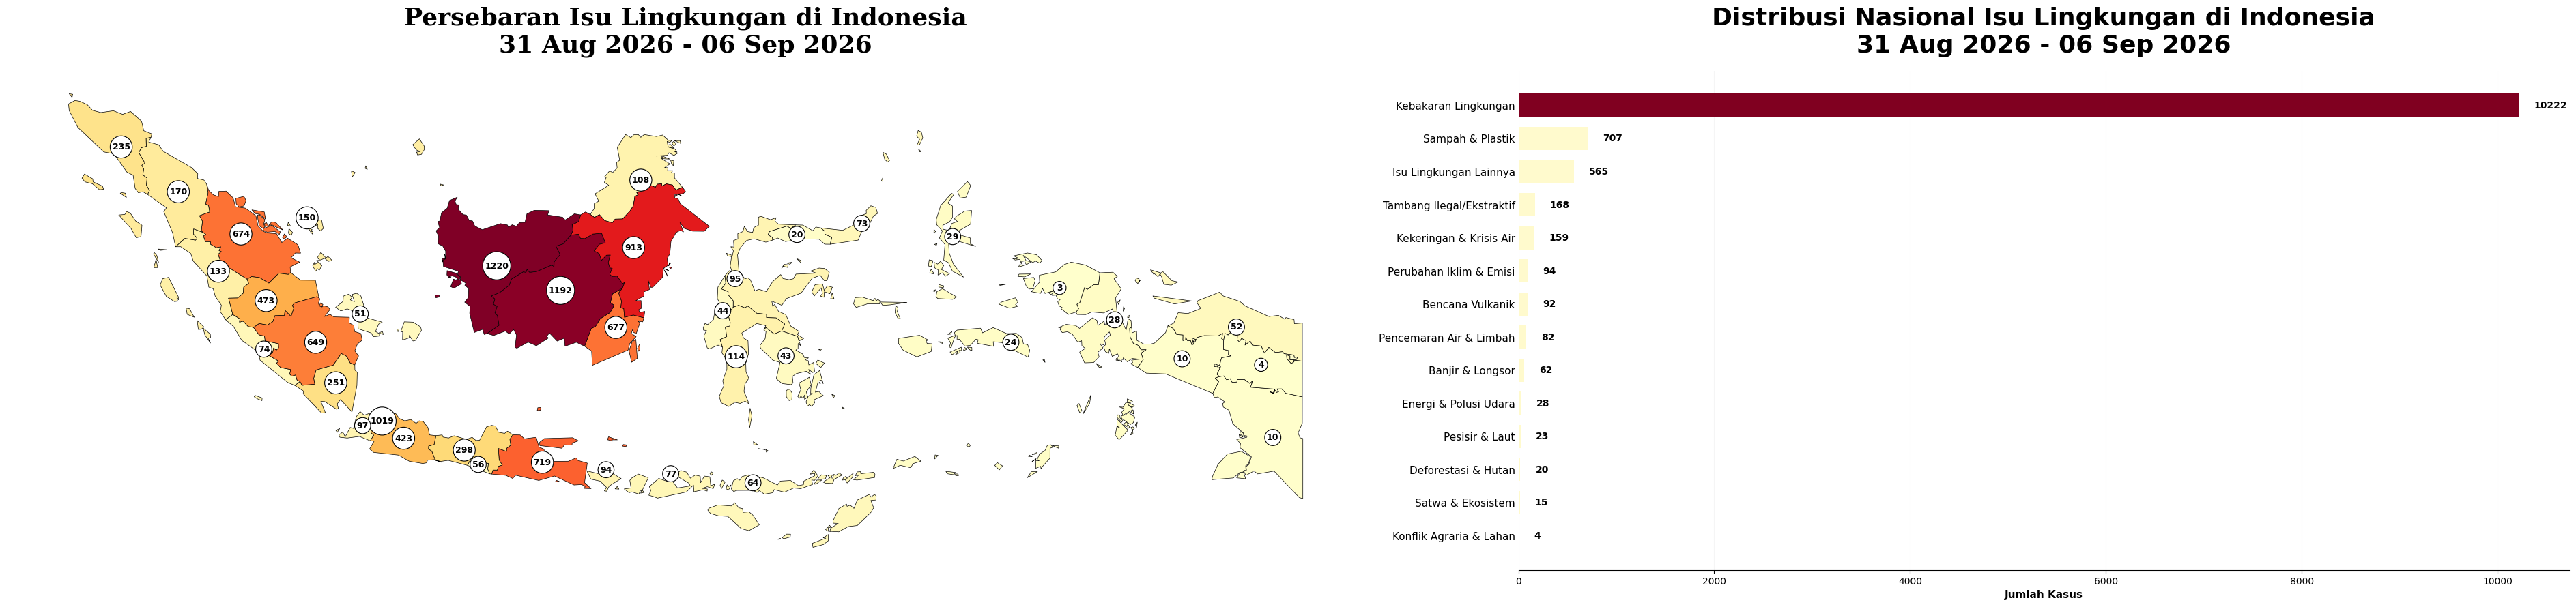


VISUALISASI SELESAI DIBUAT



In [111]:
# =========================================================
# VISUAL GABUNGAN: PETA + BAR CHART (1 FIGURE, MENYAMPING)
# =========================================================
def plot_combined(data: pd.DataFrame, start_date, end_date):
    fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(38, 9),
    gridspec_kw={"width_ratios": [1.3, 1]}
    )
    # --- SUBPLOT 1 (KIRI): PETA CHOROPLETH INDONESIA ---
    map_gdf = _get_map_gdf(data)
    if map_gdf.empty:
        print("[WARNING] Peta tidak dapat dirender.")
    else:
        prov_col = _detect_province_column(map_gdf)
        if prov_col is None:
            print("[ERROR] Kolom provinsi tidak ditemukan.")
        else:
            map_gdf.plot(
                column="jumlah_kasus", cmap=CMAP_NAME, linewidth=0.5, edgecolor="black",
                ax=ax1, legend=False,
                missing_kwds={"color": "#ffffe0", "edgecolor": "black", "linewidth": 0.5},
            )

            def _draw_badge(x, y, value):
                ax1.text(
                    x, y, f"{int(value)}", ha="center", va="center", zorder=10,
                    fontsize=9, fontweight="bold", color="black",
                    bbox=dict(boxstyle="circle,pad=0.25", facecolor="white", edgecolor="black", linewidth=0.8),
                )

            for _, row in map_gdf.iterrows():
                value = row["jumlah_kasus"]
                if value <= 0:
                    continue

                province = _normalize_name(row[prov_col])

                if province in MANUAL_BADGE_POSITION:
                    x, y = MANUAL_BADGE_POSITION[province]
                else:
                    point = _main_point(row.geometry)
                    x, y = point.x, point.y

                _draw_badge(x, y, value)

            TITLE_SIZE = 26
            ax1.set_title(
                f"Persebaran Isu Lingkungan di Indonesia\n{_format_period(start_date, end_date)}",
                fontsize=TITLE_SIZE, fontweight="bold", family="serif", pad=20,
            )
            ax1.axis("off")

    # --- SUBPLOT 2 (KANAN): BAR CHART DISTRIBUSI ISU NASIONAL ---
    if "Isu_Inti" not in data.columns:
        print("[ERROR] Kolom 'Isu_Inti' tidak ditemukan.")
    else:
        counts = data["Isu_Inti"].value_counts().sort_values(ascending=True)
        colors = (["#FFFACD"] * (len(counts) - 1) + ["#800020"]) if len(counts) > 1 else ["#800020"]
        bars = ax2.barh(counts.index, counts.values, color=colors, height=0.7)

        ax2.set_title(
            f"Distribusi Nasional Isu Lingkungan di Indonesia\n{_format_period(start_date, end_date)}",
            fontsize=TITLE_SIZE, fontweight="bold", pad=20,
        )
        ax2.set_xlabel("Jumlah Kasus", fontsize=11, fontweight="bold")
        ax2.tick_params(axis="y", labelsize=11, length=0)
        ax2.spines[["top", "right", "left"]].set_visible(False)
        ax2.xaxis.grid(True, linestyle="-", alpha=0.3, color="#e0e0e0")
        ax2.set_axisbelow(True)

        max_value = counts.max()
        for bar in bars:
            width = bar.get_width()
            ax2.text(
                width + max_value * 0.015, bar.get_y() + bar.get_height() / 2,
                f"{int(width)}", va="center", ha="left", fontsize=10, fontweight="bold",
            )

    plt.tight_layout()
    plt.show()
    return fig


print("\n" + "=" * 49)
print("MEMBUAT VISUALISASI...")
print("=" * 49 + "\n")

df_clean, start_date, end_date = prepare_data(df_clean)
fig_combined = plot_combined(df_clean, start_date, end_date)

print("\n" + "=" * 49)
print("VISUALISASI SELESAI DIBUAT")
print("=" * 49 + "\n")

trash

In [112]:
# from collections import Counter
# import re

# STOPWORDS_ID = set("""
# yang di ke dari dan atau untuk pada dengan dalam ini itu adalah akan telah
# sudah tidak juga karena oleh sebagai atas dapat bisa saat ketika para
# antara namun tetapi jika kata ada tahun hari lalu kemarin sebut ujar
# kata dia mereka kami kita saya anda tersebut baik serta hingga sekitar
# lebih dua satu tiga bagi setelah sejak selama menjadi terkait
# """.split())

# def top_terms(texts, n=40, ngram=1):
#     counter = Counter()
#     for t in texts:
#         words = re.findall(r'\b[a-z]{3,}\b', str(t).lower())
#         words = [w for w in words if w not in STOPWORDS_ID]
#         if ngram == 1:
#             counter.update(words)
#         else:
#             grams = zip(*[words[i:] for i in range(ngram)])
#             counter.update(" ".join(g) for g in grams)
#     return counter.most_common(n)

# # --- 1) Kata & frasa tersering di dokumen "Isu Lingkungan Lainnya" ---
# unclassified = df_clean.loc[df_clean["Isu_Inti"] == "Isu Lingkungan Lainnya", "search_text"]
# print(f"Jumlah dokumen belum terklasifikasi: {len(unclassified)}\n")
# print("Top kata:")
# for w, c in top_terms(unclassified, n=40, ngram=1):
#     print(f"  {w}: {c}")
# print("\nTop frasa 2 kata:")
# for p, c in top_terms(unclassified, n=30, ngram=2):
#     print(f"  {p}: {c}")

# # Baca beberapa headline mentahnya langsung
# display(df_clean.loc[df_clean["Isu_Inti"] == "Isu Lingkungan Lainnya", ["doc_id", "Mentions"]].sample(20, random_state=42))

# # --- 2) Kata & frasa tersering di dokumen yang lokasinya "Tidak Terdeteksi" ---
# no_loc = df_clean.loc[df_clean["Provinsi"] == "Tidak Terdeteksi", "search_text"]
# print(f"\nJumlah dokumen tanpa lokasi: {len(no_loc)}\n")
# print("Top kata:")
# for w, c in top_terms(no_loc, n=40, ngram=1):
#     print(f"  {w}: {c}")
# print("\nTop frasa 2 kata:")
# for p, c in top_terms(no_loc, n=30, ngram=2):
#     print(f"  {p}: {c}")

# display(df_clean.loc[df_clean["Provinsi"] == "Tidak Terdeteksi", ["doc_id", "Mentions"]].sample(20, random_state=42))